<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK2_1_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 7. 앙상블 학습과 랜덤 포레스트

**앙상블** : 분류나 회귀 모델 같은 일련의 예측기

앙상블 방법: 훈련 세트로부터 무작위로 각기 다른 서브셋을 만들어 일련의 결정 트리 분류기를 훈련 > 모든 개별 트리의 예측을 구해 예측 > 가장 많은 선택을 받은 클래스를 예측으로 삼음

**랜덤 포레스트** : 결정 트리의 앙상블, 오늘날 가장 강력한 머신러닝 알고리즘 중 하나

인기 있는 앙상블 방법 : **배깅, 부스팅, 스태킹**

### 1. 투표기반 분류기

**직접 투표(hard voting) 분류기**: 각 분류기의 예측을 모아서 가장 많이 선택된 클래스를 예측하는 것. (다수결 투표)

각 분류기가 **약한 학습기**(weak learner)일지라도 충분하게 많고 다양하다면 앙상블은 **강한 학습기**(strong learner)가 될 수 있음.

가능한 이유
> **큰 수의 법칙**: 표본집단이 클 수록 표본 평균이 모평균과 비슷해지는 것.

단! 모든 분류기가 **완벽하게 독립적이고 오차에 상관관계가 없어야** 이런 가정이 가능함.

In [11]:
# 5장에서 소개한 moons 데이터셋

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


X, y = make_moons(n_samples=300, noise=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard')
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [13]:
from sklearn.metrics import accuracy_score
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.8933333333333333
RandomForestClassifier 0.8933333333333333
SVC 0.8933333333333333
VotingClassifier 0.8933333333333333


``` voting="hard" ``` 를 ```voting="soft"```로 바꾸면 개별 분류기의 예측을 평균내어 확률이 가장 높은 클래스를 예측할 수 있음.

SVC는 기본값에서는 클래스 확률을 제공하지 않으므로 probability 매개변수를 True로 지정해야 함. (교차 검증을 사용해 훈련 속도가 느려지지만 SVC에서 predict_proba() 메서드를 사용할 수 있음.)


## 2. 배깅과 페이스팅

다양한 분류기를 만드는 또 다른 방법: 같은 알고리즘을 사용하고 훈련 세트의 서브셋을 무작위로 구성하여 분류기를 각기 다르게 학습시키는 것.

**배깅**(bootstrap aggregating): 훈련 세트에서 중복을 허용하여 샘플링하는 방식

**페이스팅**(pasting): 중복을 허용하지 않고 샘플링하는 방식



배깅의 샘플링과 훈련과정

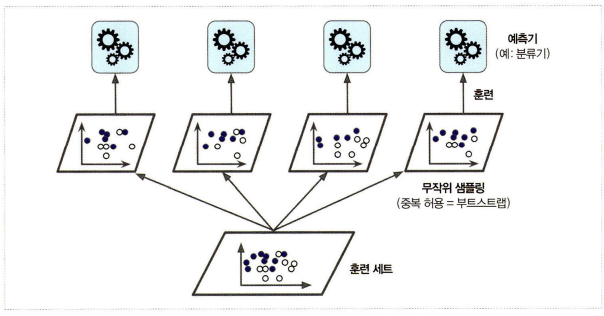

수집함수: 전형적으로 분류일 때는 **통계적 최빈값**(statistical mode)를, 회귀일 때는 **평균**을 계산함.

개별 예측기: 원본 훈련 세트로 훈련시킨 것보다 훨씬 크게 편향되어있지만 수집 함수를 통과하면 편향과 분산이 *모두* 감소.



### 2.1 사이킷런의 배깅과 페이스팅

```n_jobs```: 사이킷런이 훈련과 예측에 사용할 CPU 코어 수를 지정(-1로 지정시 가용한 모든 코어 사용)

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, n_jobs=-1)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

BaggingClassifier는 기반이 되는 분류기가 결정 트리 분류기처럼 클래스 확률을 추정할 수 있으면 직접 투표 대신 자동으로 간접 투표 방식을 사용함.

단일 결정 트리(오니쪽)과 500개 트리로 만든 배깅 앙상블(오른쪽) 비교

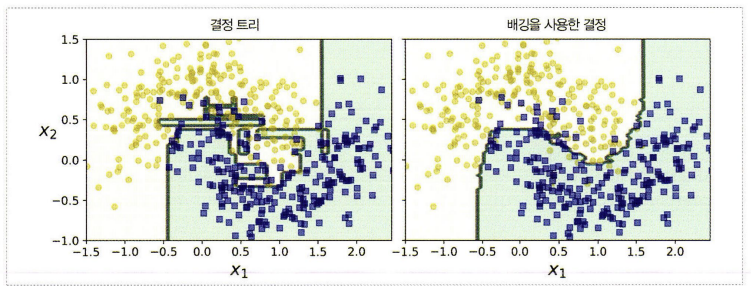

부트스트래핑: 각 예측기가 학습하는 서브셋에 다양성을 증가시키므로 배깅이 페이스팅보다 편향이 조금 더 높음.

but 다양성을 추가한다는 것은 예측기들의 상관관계를 줄이므로 앙상블의 분산을 감소시킴.


### 2.2 oob 평가

BaggingClassifier는 기본값으로 중복을 허용하여(bootstrap=True) 훈련 세트의 크기만큼인 m개 샘플을 선택. > 평균적으로 훈련 샘플의 63% 정도만 샘플링된다는 것을 의미.

선택되지 않은 훈련 샘플의 나머지 37%를 **oob**(out-of-bag) 샘플이라고 함.

앙상블의 평가는 각 예측기의 oob 평가를 평균하여 얻음.

BaggingClassifier를 만들 때 oob_score=True로 지정 시, 훈련이 끝난 후 자동으로 oob 평가를 수행.
> oob_score_ 변수에 저장되어 있음.

In [15]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    bootstrap=True, n_jobs=-1, oob_score=True)

bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.8933333333333333

In [16]:
from sklearn.metrics import accuracy_score

y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8933333333333333

In [17]:
# oob 샘플에 대한 결정 함수의 값은 oob_decision_function_ 변수에서 확인할 수 있음.
# 이 경우 결정 함수는 각 훈련 샘플의 클래스 확률을 반환.

bag_clf.oob_decision_function_

array([[0.        , 1.        ],
       [0.00540541, 0.99459459],
       [0.06217617, 0.93782383],
       [1.        , 0.        ],
       [0.93604651, 0.06395349],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.85714286, 0.14285714],
       [0.0049505 , 0.9950495 ],
       [0.56321839, 0.43678161],
       [0.        , 1.        ],
       [0.59574468, 0.40425532],
       [0.94680851, 0.05319149],
       [1.        , 0.        ],
       [0.97674419, 0.02325581],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.01123596, 0.98876404],
       [0.80978261, 0.19021739],
       [0.01604278, 0.98395722],
       [0.28333333, 0.71666667],
       [0.02040816, 0.97959184],
       [0.01704545, 0.98295455],
       [0.75690608, 0.24309392],
       [1.        , 0.        ],
       [0.01612903, 0.98387097],
       [0.98058252, 0.01941748],
       [0.07734807, 0.92265193],
       [0.00558659, 0.99441341],
       [0.98029557, 0.01970443],
       [0.

## 3. 랜덤 패치와 랜덤 서브스페이스

BaggingClassifier는 특성 샘플링도 지원
> 두 매개변수로 조절.
- max_features
- bootsrap_features

**랜덤 패치 방식**(random patches method): 훈련 특성과 샘플을 모두 샘플링하는 것

**랜덤 서브스페이스 방식**(random subspaces method): 훈련 샘플을 모두 사용하고(```bootstrap=False, max_samples=1.0```설정) 특성은 샘플링하는 것(```bootstrap_features=True``` 그리고/또는 ```max_features```는 1.0보다 작게 설정)



## 4. 랜덤 포레스트
- 배깅 방법(또느 페이스팅)을 적용한 결정 트리의 앙상블
- max_samples: 훈련 세트의 크기
- ```RandomForestClassifier```사용.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)

랜덤 포레스트 알고리즘
- 트리의 노드를 분할할 때 전체 특성 중에서 최선의 특성을 찾는 대신 무작위로 선택한 특성 후보 중에서 최적의 특성을 찾는 식으로 무작위성을 더 주입

In [19]:
# BaggingClassifier로 RandomForestClassifier랑 유사하게 만들기

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="auto", max_leaf_nodes=16),
    n_estimators=500, max_samples=1.0, bootstrap=True, n_jobs=-1)

### 4.1 엑스트라 트리

**익스트림 랜덤 트리**(extremely randomized trees): 최적의 임곗값을 찾는 대신 후보 특성을 사용해 무작위로 분할한 다음 그중에서 최상의 분할을 선택하는 극단적으로 무작위한 트리의 랜덤 포레스트
> 편향이 늘어나지만 대신 분산을 낮춤.
> 일반적인 랜덤 포레스트보다 엑스트라 트리가 훨씬 빠름

- ```ExtraTreesClassifier```사용


### 4.2 특성 중요도

랜덤 포레스트의 장점: 특성의 상대적 중요도를 측정하기 쉬움.
- 어떤 특성을 사용한 노드가 평균적으로 불순도를 얼마나 감소시키는지 확인하여 특성의 중요도를 측정


In [20]:
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500, n_jobs = -1)
rnd_clf.fit(iris["data"], iris["target"])
for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.08445044974054902
sepal width (cm) 0.02243426924971275
petal length (cm) 0.44947616098226045
petal width (cm) 0.44363912002747785
